In [1]:
#Implementacion de algoritmo DBSCAN con libreria sklearn
import sklearn
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("WineQT.csv")
counter = df["quality"].value_counts()

print("Distribución de clases:")
print(counter)

target = "quality"
features = df.columns[(df.columns != target) & (df.columns != "Id")] #Todas las columnas menos la columna target y la columna id

Distribución de clases:
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


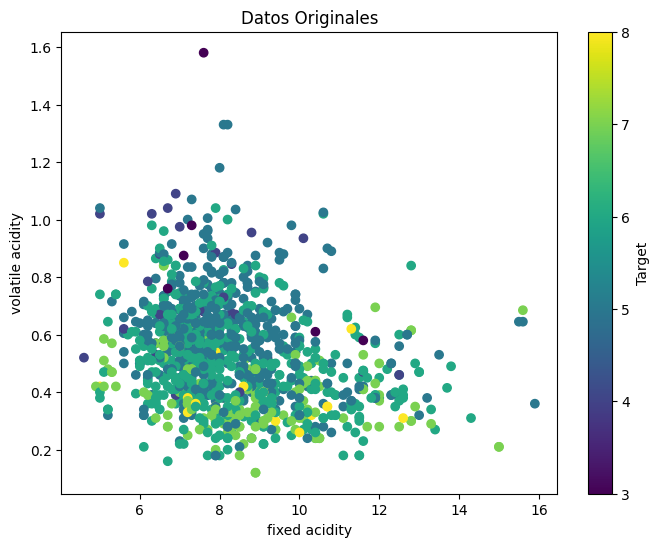

In [2]:
#Visualización de los datos originales

plt.figure(figsize=(8, 6))
plt.scatter(
    df[features[0]],
    df[features[1]],
    c=df[target],
    cmap="viridis"
)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Datos Originales")
plt.colorbar(label="Target")

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[features], df['quality'], test_size=0.3, random_state=42)

DBSCAN agrupa datos basandose en cercania y densidad.
Las caracteristicas de nuestro dataset son las "dimensiones" de los datos.
Con esas mismas dimensiones es como DBSCAN determina si un punto pertenece a un cluster o es ruido.
Ya que tenemos un dataset con muchas dimensiones, es matematicamente complejo calcular distancias entre datos con tantas dimensiones. Tener muchas dimensiones ademas causa un problema muy conocido en DBSCAN conocido como el "Curse of Dimensionality". A medida que aumenta el número de dimensiones las distancias entre puntos tienden a volverse más uniformes por lo queremos reducir las dimensiones lo mas posible.
Para esto, vamos a utilizar PCA (Principal Component Analysis)

[0.28394496 0.17614015 0.14487063 0.10578763 0.09051892 0.05856399
 0.04962768 0.03706015 0.03141561 0.01675591 0.00531439]


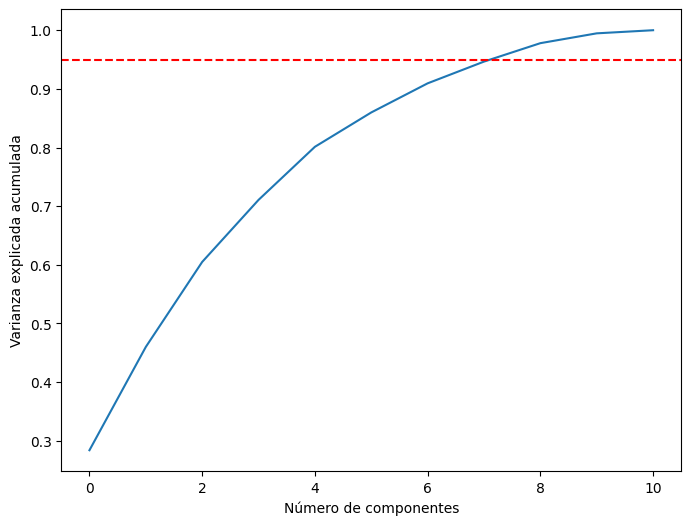

In [4]:
# Aplicar PCA para reducir la dimensionalidad
# Antes de decidir cuantas dimensiones queremos, calculamos la varianza explicada por cada componente principal para decidir cuantas dimensiones queremos.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca_full = PCA().fit(X_train_scaled)
print(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

Se puede ver en la grafica que el 95% de varianza se explica entre el componente 6 y 8. Entones, con esa informacion, podemos reducir las caracteristicas a 7 y mantener el 95% de la informacion original.

[[0.         0.73929412 2.16136353 2.36614888 2.41054536]
 [0.         0.71883602 0.72087471 0.85853829 0.93545426]
 [0.         2.08730653 3.32595932 3.42221159 3.75141418]
 [0.         1.70473316 1.74182324 1.77207379 1.79170144]
 [0.         0.10956877 0.21812428 0.35182077 0.41340898]]
[[  0 529 227 135 131]
 [  1 649 270  80 231]
 [  2 791 395 667 689]
 [  3 289 746 637 356]
 [  4 275  94 424 235]]
[[0.         0.         0.         0.         0.37256155]
 [0.         0.         0.         0.         0.39589391]
 [0.         0.         0.         0.         0.41340898]
 [0.         0.         0.         0.         0.41340898]
 [0.         0.         0.         0.34680264 0.41340898]]
Knee point: 2.684995686797777


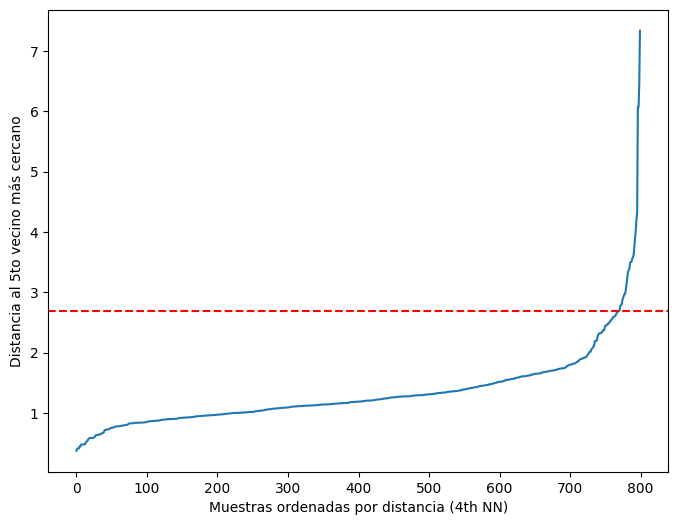

In [5]:
#Preparar los datos para DBSCAN
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

from sklearn.neighbors import NearestNeighbors
# Calcular las distancias a los k vecinos más cercanos
nbrs = NearestNeighbors(n_neighbors=5).fit(X_train_pca)

#Encontrar los k vecinos de un punto
distances, indices = nbrs.kneighbors(X_train_pca)
print(distances[:5])  # Muestra las distancias a los 5 vecinos más cercanos para las primeras 5 muestras
print(indices[:5])  # Muestra los índices de los 5 vecinos más cercanos para las primeras 5 muestras

sorted_distances = np.sort(distances, axis=0)
print(sorted_distances[:5])  # Muestra las distancias ordenadas a los 5 vecinos más cercanos para las primeras 5 muestras

#Plotear la "knee" para identificar los puntos que pertenecen al cluster y los que son ruido
k_distances = sorted_distances[:, 4]  # Tomamos la distancia al 5to vecino más cercano

# Antes de plotear, obtener donde esta el "knee" exacto
import kneed
from kneed import KneeLocator

knee_locator = KneeLocator(x = range(1, len(distances)+1), y = k_distances, curve="convex", direction="increasing")

knee_point = knee_locator.knee_y

print(f"Knee point: {knee_point}")
plt.figure(figsize=(8, 6))
plt.plot(k_distances)
plt.axhline(y=knee_point, color='r', linestyle='--', label=f'Knee Point: {knee_point:.2f}')
plt.xlabel("Muestras ordenadas por distancia (4th NN)")
plt.ylabel("Distancia al 5to vecino más cercano")
plt.show()

Ahora si, creamos el modelo

In [ ]:
#EPS sera el knee que encontramos, y min_samples sera 5 (ya que es el numero de vecinos que usamos para calcular la distancia)
clusters_train =  DBSCAN(eps=knee_point, min_samples=5).fit(X_train_pca)

from collections import Counter
print(Counter(clusters_train.labels_))

from sklearn.metrics import adjusted_rand_score
print(Counter(clusters_train.labels_))

Counter({np.int64(0): 783, np.int64(-1): 13, np.int64(1): 4})
Counter({np.int64(0): 783, np.int64(-1): 13, np.int64(1): 4})
ARI: 0.0021686422931406065


In [7]:
df_scaled_features = pd.DataFrame(X_train_pca)

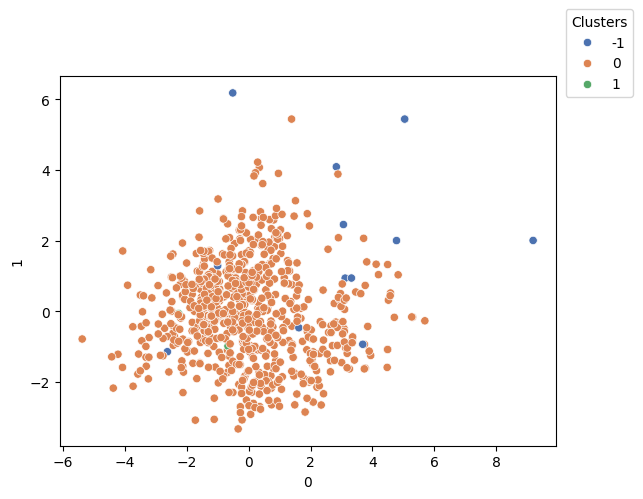

In [8]:
import seaborn as sns
p = sns.scatterplot(data=df_scaled_features, x=df_scaled_features[0], y=df_scaled_features[1], hue=clusters_train.labels_, legend="full", palette="deep")
sns.move_legend(p, "upper right", bbox_to_anchor=(1.17, 1.2), title='Clusters')
plt.show()

Aun con PCA, no pudimos reducir las dimensiones suficiente y los efectos de "Curse of Dimensionality" se siguen viendo, dandonos solo un cluster mal distribuido con muchos datos clasificados como ruido.